# Sistema Inteligente de Recomendación de Noticias del Perú
## Modelado de Temas con NMF y Similitud del Coseno


### Importación de librería

In [1]:
# =====================================================
# Importación de librerías
# =====================================================
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titleweight": "bold",
    "font.size": 10,
})

COLOR_PRINCIPAL = "#00538C"   # azul institucional
COLOR_SECUNDARIO = "#C8A000"  # dorado institucional

### Carga del dataset


In [3]:
# =====================================================
# Carga de datos
# =====================================================
RUTA_DATASET = "peru_news_dataset.csv"

df_noticias = pd.read_csv(RUTA_DATASET)
df_noticias["fecha"] = pd.to_datetime(df_noticias["fecha"], utc=True, errors="coerce")
df_noticias["texto_crudo"] = (
    df_noticias["titulo"].fillna("") + ". " + df_noticias["contenido"].fillna("")
)

print(f"Dimensiones del dataset: {df_noticias.shape}")
df_noticias.head(3)

Dimensiones del dataset: (69, 6)


,titulo,contenido,fecha,fuente,url,texto_crudo
0,Emiliano Zecca: “Hoy parece una discusión tont...,“Smoke” (1995) es una película dirigida por Wa...,2026-07-12 22:45:00+00:00,https://elcomercio.pe/arc/outboundfeeds/rss/?o...,https://elcomercio.pe/eldominical/entrevista/e...,Emiliano Zecca: “Hoy parece una discusión tont...
1,"Temblor en Colombia hoy, domingo 12 de julio: ...","¿Se puede predecir un sismo?\n\nActualmente, e...",2026-07-12 22:33:52+00:00,https://elcomercio.pe/arc/outboundfeeds/rss/?o...,https://elcomercio.pe/respuestas/colombia/temb...,"Temblor en Colombia hoy, domingo 12 de julio: ..."
2,"Temblor en México hoy, domingo 12 de julio: ma...",Regiones Sísmicas en México y sus clasificacio...,2026-07-12 22:32:21+00:00,https://elcomercio.pe/arc/outboundfeeds/rss/?o...,https://elcomercio.pe/respuestas/mexico/temblo...,"Temblor en México hoy, domingo 12 de julio: ma..."


### Derivación de la categoría editorial



In [4]:
# =====================================================
# Derivación de categoría editorial a partir de la URL
# =====================================================
def extraer_categoria_editorial(url):
    '''Extrae el primer segmento de ruta de la URL como categoría editorial aproximada.'''
    coincidencia = re.search(r"elcomercio\.pe/([a-z0-9\-]+)/", str(url))
    return coincidencia.group(1) if coincidencia else "sin_categoria"


def extraer_nombre_medio(url):
    '''Obtiene un nombre de medio legible a partir del dominio de la URL.'''
    coincidencia = re.search(r"https?://(?:www\.)?([a-z0-9\-]+)\.", str(url))
    dominio = coincidencia.group(1) if coincidencia else "desconocido"
    return dominio.replace("elcomercio", "El Comercio").title()


df_noticias["categoria"] = df_noticias["url"].apply(extraer_categoria_editorial)
df_noticias["medio"] = df_noticias["url"].apply(extraer_nombre_medio)

df_noticias[["titulo", "categoria", "medio"]].head(5)

,titulo,categoria,medio
0,Emiliano Zecca: “Hoy parece una discusión tont...,eldominical,El Comercio
1,"Temblor en Colombia hoy, domingo 12 de julio: ...",respuestas,El Comercio
2,"Temblor en México hoy, domingo 12 de julio: ma...",respuestas,El Comercio
3,"Temblor en Venezuela hoy, domingo 12 de julio:...",respuestas,El Comercio
4,Pedro Castillo presenta dos nuevas solicitudes...,politica,El Comercio


### Limpieza y preprocesamiento del texto



In [5]:
# =====================================================
# Limpieza y preprocesamiento de texto
# =====================================================
STOPWORDS_ESPANOL = set('''
de la que el en y a los del se las por un para con no una su al lo como más pero sus le ya o
este sí porque esta entre cuando muy sin sobre también me hasta hay donde quien desde todo nos
durante todos uno les ni contra otros ese eso ante ellos e esto mí antes algunos qué unos yo
otro otras otra él tanto esa estos mucho quienes nada muchos cual poco ella estar estas algunas
algo nosotros mi mis tú te ti tu tus ellas nosotras vosotros vosotras os mío mía míos mías
tuyo tuya tuyos tuyas suyo suya suyos suyas nuestro nuestra nuestros nuestras vuestro vuestra
vuestros vuestras esos esas estoy estás está estamos estáis están esté estés estemos estéis
estén estaré estarás estará estaremos estaréis estarán estaria estarías estaría estaríamos
estaríais estarían era eras éramos erais eran fui fuiste fue fuimos fuisteis fueron sea seas
seamos seáis sean seré serás será seremos seréis serán sería serías seríamos seríais serían
he has ha hemos habéis han había habías habíamos habíais habían habré habrás habrá habremos
habréis habrán habría habrías habríamos habríais habrían son soy eres somos sois siendo sido
tenía tenías teníamos teníais tenían tuve tuviste tuvo tuvimos tuvisteis tuvieron tendré
tendrás tendrá tendremos tendréis tendrán tendría tendrías tendríamos tendríais tendrían
tengo tienes tiene tenemos tenéis tienen según cada cómo aunque además así mismo bien tras
ser hace hacer puede pueden dijo dice dijeron indicó señaló afirmó dos tres años año día días
ndash nbsp cuenta parte manera vez veces mientras solo sólo pues aún mediante ver caso casos
'''.split())


def limpiar_texto(texto, stopwords=STOPWORDS_ESPANOL, longitud_minima_palabra=3):
    '''Normaliza un texto: minúsculas, sin URLs/números/símbolos, sin stopwords.'''
    texto = texto.lower()
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)          # URLs
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)            # solo letras (incl. tildes y ñ)
    texto = re.sub(r"\s+", " ", texto).strip()                # espacios dobles/múltiples

    palabras = [
        palabra for palabra in texto.split()
        if palabra not in stopwords and len(palabra) >= longitud_minima_palabra
    ]
    return " ".join(palabras)


df_noticias["texto_limpio"] = df_noticias["texto_crudo"].apply(limpiar_texto)

print("Ejemplo de limpieza de texto:\n")
print("ANTES:", df_noticias.loc[0, "texto_crudo"][:200], "...\n")
print("DESPUÉS:", df_noticias.loc[0, "texto_limpio"][:200], "...")

Ejemplo de limpieza de texto:

ANTES: Emiliano Zecca: “Hoy parece una discusión tonta hablar sobre los daños a la salud del tabaco, pero la discusión se repite”. “Smoke” (1995) es una película dirigida por Wayne Wang, con el escritor neoy ...

DESPUÉS: emiliano zecca hoy parece discusión tonta hablar daños salud tabaco discusión repite smoke película dirigida wayne wang escritor neoyorquino paul auster guionista título ambiguo referirse cualquier ti ...


###  Análisis exploratorio de datos (EDA)


In [6]:
# =====================================================
# Análisis exploratorio: estadísticas generales
# =====================================================
df_noticias["longitud_palabras"] = df_noticias["texto_limpio"].str.split().str.len()

print("=" * 55)
print("ESTADÍSTICAS GENERALES DEL CORPUS")
print("=" * 55)
print(f"Número total de noticias        : {len(df_noticias)}")
print(f"Número de categorías editoriales: {df_noticias['categoria'].nunique()}")
print(f"Número de medios distintos      : {df_noticias['medio'].nunique()}")
print(f"Rango de fechas                 : {df_noticias['fecha'].min():%d-%m-%Y} a {df_noticias['fecha'].max():%d-%m-%Y}")
print()
print("Longitud de las noticias (en palabras, tras limpieza):")
print(df_noticias["longitud_palabras"].describe().round(2).to_string())

ESTADÍSTICAS GENERALES DEL CORPUS
Número total de noticias        : 69
Número de categorías editoriales: 15
Número de medios distintos      : 1
Rango de fechas                 : 10-06-2026 a 12-07-2026

Longitud de las noticias (en palabras, tras limpieza):
count     69.00
mean     345.62
std      171.20
min      116.00
25%      231.00
50%      295.00
75%      428.00
max      933.00


In [7]:
# =====================================================
# Análisis exploratorio: noticias por fuente/medio
# =====================================================
conteo_por_medio = df_noticias["medio"].value_counts()
print("Noticias por medio:")
print(conteo_por_medio.to_string())

if conteo_por_medio.nunique() == 1:
    print("\nNota: el dataset proviene de un único medio (El Comercio), por lo que el "
          "análisis por 'fuente' resulta homogéneo. Por ello, el análisis exploratorio "
          "se enriquece a continuación con la categoría editorial derivada de la URL, "
          "que sí aporta variedad temática relevante para este proyecto.")

Noticias por medio:
medio
El Comercio    69

Nota: el dataset proviene de un único medio (El Comercio), por lo que el análisis por 'fuente' resulta homogéneo. Por ello, el análisis exploratorio se enriquece a continuación con la categoría editorial derivada de la URL, que sí aporta variedad temática relevante para este proyecto.


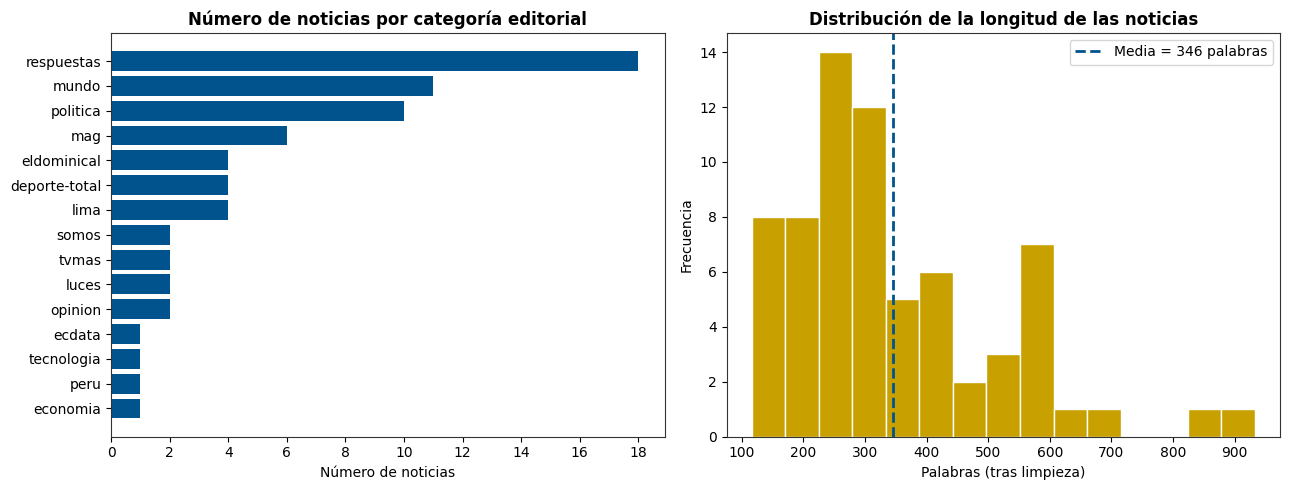

In [8]:
# =====================================================
# Análisis exploratorio: visualizaciones profesionales
# =====================================================
conteo_por_categoria = df_noticias["categoria"].value_counts()

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

ejes[0].barh(conteo_por_categoria.index[::-1], conteo_por_categoria.values[::-1],
             color=COLOR_PRINCIPAL)
ejes[0].set_title("Número de noticias por categoría editorial")
ejes[0].set_xlabel("Número de noticias")
ejes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ejes[1].hist(df_noticias["longitud_palabras"], bins=15, color=COLOR_SECUNDARIO,
             edgecolor="white")
ejes[1].axvline(df_noticias["longitud_palabras"].mean(), color=COLOR_PRINCIPAL,
                linestyle="--", linewidth=2,
                label=f"Media = {df_noticias['longitud_palabras'].mean():.0f} palabras")
ejes[1].set_title("Distribución de la longitud de las noticias")
ejes[1].set_xlabel("Palabras (tras limpieza)")
ejes[1].set_ylabel("Frecuencia")
ejes[1].legend()

plt.tight_layout()
plt.show()

###  Vectorización con TF-IDF



In [9]:
# =====================================================
# Vectorización TF-IDF
# =====================================================
vectorizador_tfidf = TfidfVectorizer(
    max_df=0.9,
    min_df=2,
    ngram_range=(1, 2),
    max_features=3000,
)

matriz_tfidf = vectorizador_tfidf.fit_transform(df_noticias["texto_limpio"])

print(f"Dimensiones de la matriz TF-IDF: {matriz_tfidf.shape}")
print(f"Tamaño del vocabulario         : {len(vectorizador_tfidf.get_feature_names_out())}")
print(f"Dispersión (sparsity) de la matriz: "
      f"{100 * (1 - matriz_tfidf.nnz / (matriz_tfidf.shape[0] * matriz_tfidf.shape[1])):.2f}%")

Dimensiones de la matriz TF-IDF: (69, 3000)
Tamaño del vocabulario         : 3000
Dispersión (sparsity) de la matriz: 94.08%


###  Modelado de temas con NMF



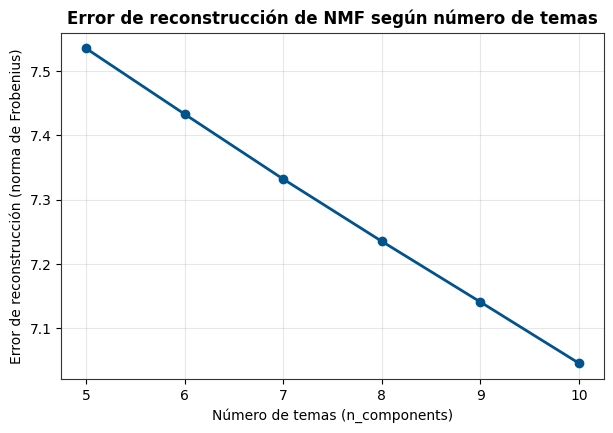

  n_components = 5 -> error = 7.5356
  n_components = 6 -> error = 7.4333
  n_components = 7 -> error = 7.3321
  n_components = 8 -> error = 7.2352
  n_components = 9 -> error = 7.1408
  n_components = 10 -> error = 7.0455


In [10]:
# =====================================================
# Selección del número de temas (5 a 10)
# =====================================================
RANGO_NUM_TEMAS = range(5, 11)
errores_reconstruccion = []

for num_temas in RANGO_NUM_TEMAS:
    modelo_prueba = NMF(
        n_components=num_temas, init="nndsvda", random_state=RANDOM_STATE, max_iter=500
    )
    modelo_prueba.fit(matriz_tfidf)
    errores_reconstruccion.append(modelo_prueba.reconstruction_err_)

plt.figure(figsize=(7, 4.5))
plt.plot(list(RANGO_NUM_TEMAS), errores_reconstruccion, marker="o",
         color=COLOR_PRINCIPAL, linewidth=2)
plt.title("Error de reconstrucción de NMF según número de temas")
plt.xlabel("Número de temas (n_components)")
plt.ylabel("Error de reconstrucción (norma de Frobenius)")
plt.grid(alpha=0.3)
plt.show()

for num_temas, error in zip(RANGO_NUM_TEMAS, errores_reconstruccion):
    print(f"  n_components = {num_temas} -> error = {error:.4f}")

In [11]:
# =====================================================
# Entrenamiento del modelo NMF final
# =====================================================
NUM_TEMAS = 7

modelo_nmf = NMF(
    n_components=NUM_TEMAS,
    init="nndsvda",
    random_state=RANDOM_STATE,
    max_iter=500,
    l1_ratio=0.0,
)

matriz_documento_tema = modelo_nmf.fit_transform(matriz_tfidf)

print(f"Modelo NMF entrenado con {NUM_TEMAS} temas.")
print(f"Error de reconstrucción final : {modelo_nmf.reconstruction_err_:.4f}")
print(f"Iteraciones hasta convergencia: {modelo_nmf.n_iter_}")

Modelo NMF entrenado con 7 temas.
Error de reconstrucción final : 7.3321
Iteraciones hasta convergencia: 316


###  Palabras más representativas por tema



In [12]:
# =====================================================
# Tabla de palabras principales por tema
# =====================================================
NUM_PALABRAS_POR_TEMA = 10
nombres_terminos = np.array(vectorizador_tfidf.get_feature_names_out())

tabla_temas = {}
for indice_tema, pesos_tema in enumerate(modelo_nmf.components_):
    indices_top = pesos_tema.argsort()[::-1][:NUM_PALABRAS_POR_TEMA]
    tabla_temas[f"Tema {indice_tema}"] = nombres_terminos[indices_top]

df_temas = pd.DataFrame(tabla_temas)
df_temas

,Tema 0,Tema 1,Tema 2,Tema 3,Tema 4,Tema 5,Tema 6
0,castillo,mundial,sismo,pago,lima,francia,diego
1,bancada,semifinales,magnitud,gratificación,perú,rajoy,granja
2,gobierno,argentina,méxico,trabajadores,venezuela,racismo,chávarri
3,popular,fútbol,sísmica,sueldo,viviendas,expresidente,vip
4,partido,inglaterra,sismos,laboral,salud,francesa,granja vip
5,diputados,messi,temblor,beneficio,país,españa,shirley
6,fujimori,final,zonas,trabajador,amor,selección,gabriela
7,sánchez,partidos,actividad,monto,personas,selección francesa,arica
8,fuerza,selecciones,terremoto,julio,vida,español,shirley arica
9,pedro castillo,partido,predecir,ley,libro,gobierno,diego chávarri


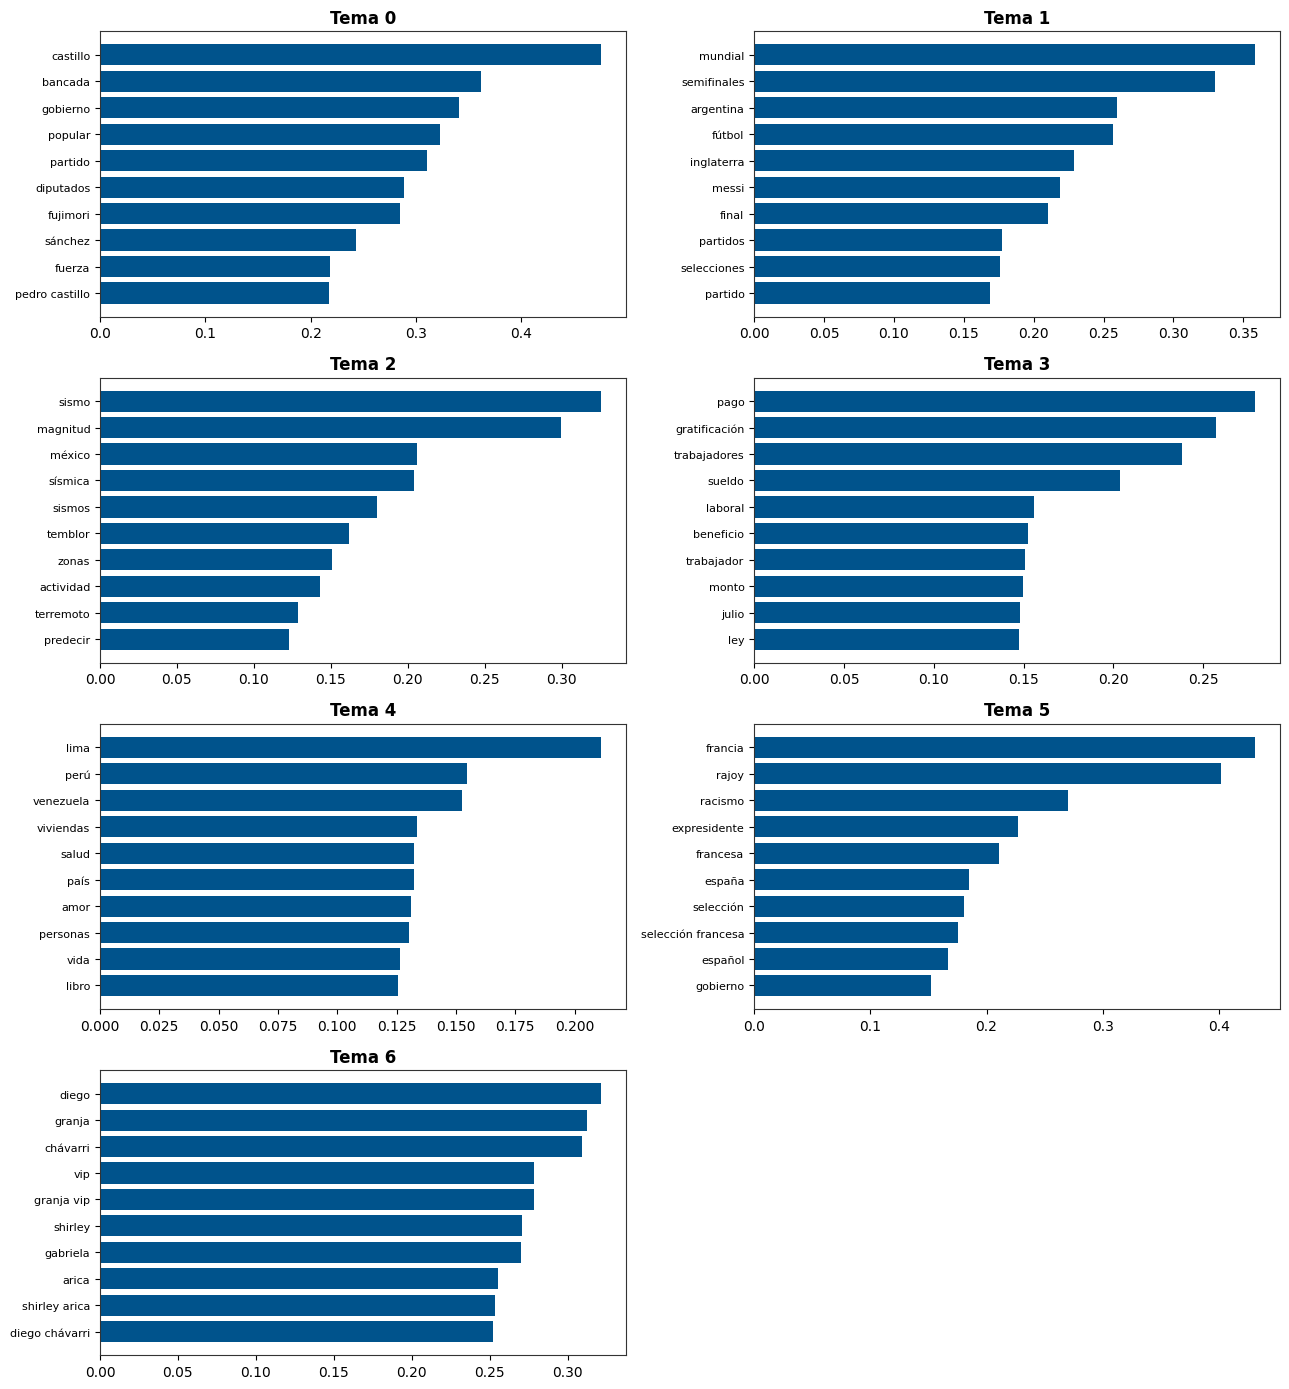

In [13]:
# =====================================================
# Visualización de las palabras principales por tema
# =====================================================
fig, ejes = plt.subplots(4, 2, figsize=(13, 14))
ejes = ejes.flatten()

for indice_tema, pesos_tema in enumerate(modelo_nmf.components_):
    indices_top = pesos_tema.argsort()[::-1][:NUM_PALABRAS_POR_TEMA]
    palabras = nombres_terminos[indices_top]
    pesos = pesos_tema[indices_top]

    eje = ejes[indice_tema]
    eje.barh(palabras[::-1], pesos[::-1], color=COLOR_PRINCIPAL)
    eje.set_title(f"Tema {indice_tema}")
    eje.tick_params(axis="y", labelsize=8)

for eje_sobrante in ejes[NUM_TEMAS:]:
    eje_sobrante.axis("off")

plt.tight_layout()
plt.show()

###  Construcción de la matriz de similitud del coseno



In [14]:
# =====================================================
# Matriz de similitud del coseno entre noticias
# =====================================================
matriz_similitud = cosine_similarity(matriz_documento_tema)

print(f"Dimensiones de la matriz de similitud: {matriz_similitud.shape}")
print(f"(Cada noticia comparada contra las {len(df_noticias)} noticias del corpus, incluida ella misma)")

Dimensiones de la matriz de similitud: (69, 69)
(Cada noticia comparada contra las 69 noticias del corpus, incluida ella misma)


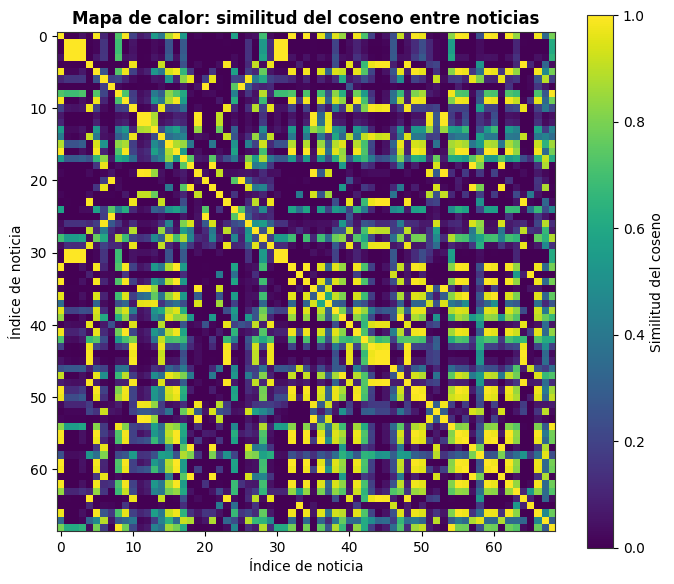

In [15]:
# =====================================================
# Visualización de la matriz de similitud (mapa de calor)
# =====================================================
plt.figure(figsize=(7, 6))
mapa_calor = plt.imshow(matriz_similitud, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(mapa_calor, label="Similitud del coseno")
plt.title("Mapa de calor: similitud del coseno entre noticias")
plt.xlabel("Índice de noticia")
plt.ylabel("Índice de noticia")
plt.tight_layout()
plt.show()

###  Sistema de recomendación de noticias



In [16]:
# =====================================================
# Función principal: recomendar_noticias
# =====================================================
def recomendar_noticias(indice, top_n=5):
    '''
    Recomienda noticias con temática similar a la noticia indicada.

    Parámetros
    ----------
    indice : int
        Índice (posición en df_noticias) de la noticia de referencia.
    top_n : int
        Número de noticias recomendadas a devolver.

    Retorna
    -------
    pd.DataFrame
        Tabla con título, medio, categoría editorial y score de similitud (%)
        de las noticias recomendadas, ordenadas de mayor a menor similitud.
    '''
    if indice < 0 or indice >= len(df_noticias):
        raise ValueError(f"El índice debe estar entre 0 y {len(df_noticias) - 1}")

    puntuaciones = matriz_similitud[indice]
    orden_descendente = np.argsort(puntuaciones)[::-1]
    orden_descendente = orden_descendente[orden_descendente != indice][:top_n]

    recomendaciones = df_noticias.loc[
        orden_descendente, ["titulo", "medio", "categoria"]
    ].copy()
    recomendaciones["score_similitud"] = (puntuaciones[orden_descendente] * 100).round(2)

    return recomendaciones.reset_index().rename(columns={"index": "indice_original"})

###  Demostración con noticias reales



In [17]:
# =====================================================
# Función auxiliar para mostrar una demostración completa
# =====================================================
def mostrar_demostracion(indice, top_n=5):
    '''Imprime la noticia original y sus recomendaciones de forma legible.'''
    noticia_original = df_noticias.loc[indice]

    print("=" * 80)
    print(f"NOTICIA ORIGINAL (índice {indice}) | Categoría: {noticia_original['categoria']}")
    print("=" * 80)
    print(noticia_original["titulo"])
    print()

    recomendaciones = recomendar_noticias(indice, top_n)
    print(f"Top {top_n} noticias recomendadas:\n")
    for posicion, fila in recomendaciones.iterrows():
        print(f"  {posicion + 1}. (idx={fila['indice_original']}, "
              f"cat={fila['categoria']}, score={fila['score_similitud']}%)")
        print(f"     {fila['titulo']}")
    print()

In [18]:
# =====================================================
# Ejemplo 1: noticia sobre política peruana (Pedro Castillo)
# =====================================================
indice_ejemplo_politica = df_noticias[
    df_noticias["titulo"].str.contains("Castillo", case=False, na=False)
].index[0]

mostrar_demostracion(indice_ejemplo_politica, top_n=5)

NOTICIA ORIGINAL (índice 4) | Categoría: politica
Pedro Castillo presenta dos nuevas solicitudes para acceder a una gracia presidencial: ¿Cuáles son los argumentos que utiliza?

Top 5 noticias recomendadas:

  1. (idx=64, cat=politica, score=100.0%)
     La influencia de Pedro Castillo en las bancadas del Congreso bicameral: La interna de Juntos por el Perú
  2. (idx=44, cat=politica, score=99.6%)
     El Congreso de los desobedientes, una crónica de Fernando Vivas
  3. (idx=23, cat=politica, score=99.6%)
     Renovación Popular postulará a Norma Yarrow para la Mesa Directiva de la Cámara de Diputados: entretelones de las conversaciones y acercamientos
  4. (idx=48, cat=politica, score=99.5%)
     El 73% cree que la prioridad del gobierno de Keiko Fujimori debe ser combatir la inseguridad
  5. (idx=45, cat=opinion, score=99.47%)
     Cuenta regresiva



In [19]:
# =====================================================
# Ejemplo 2: noticia deportiva (fútbol)
# =====================================================
indice_ejemplo_deporte = df_noticias[df_noticias["categoria"] == "deporte-total"].index[0]
mostrar_demostracion(indice_ejemplo_deporte, top_n=5)

NOTICIA ORIGINAL (índice 11) | Categoría: deporte-total
Messi, seis mundiales después: los cinco récords imposibles que rompió y un clásico ante Inglaterra para agrandar su leyenda

Top 5 noticias recomendadas:

  1. (idx=12, cat=deporte-total, score=99.93%)
     El día después de Messi y Cristiano: ¿quién es el heredero del trono a rey del mundo cuando acabe la Copa?
  2. (idx=53, cat=respuestas, score=99.83%)
     Semifinales del Mundial 2026: cruces, horarios y en qué canales ver los partidos
  3. (idx=35, cat=respuestas, score=99.73%)
     ¿A qué hora empiezan los partidos por las semifinales del Mundial 2026?
  4. (idx=19, cat=respuestas, score=99.7%)
     Scaloni pide a los argentinos ver solo “como un partido de fútbol” el duelo crucial ante Inglaterra por las semifinales del Mundial 2026
  5. (idx=51, cat=mundo, score=97.78%)
     Al menos dos muertos en Argentina durante el partido y los festejos por el 3-1 ante Suiza



In [20]:
# =====================================================
# Ejemplo 3: noticia sobre un tema distinto (sismos)
# =====================================================
indice_ejemplo_sismo = df_noticias[
    df_noticias["titulo"].str.contains("emblor", case=False, na=False)
].index[0]

mostrar_demostracion(indice_ejemplo_sismo, top_n=5)

NOTICIA ORIGINAL (índice 1) | Categoría: respuestas
Temblor en Colombia hoy, domingo 12 de julio: epicentro, magnitud y hora

Top 5 noticias recomendadas:

  1. (idx=31, cat=mag, score=100.0%)
     Temblor en México EN VIVO hoy, 12 de julio 2026: hora exacta, magnitud y dónde fue el epicentro del último mismo vía SSN
  2. (idx=2, cat=respuestas, score=100.0%)
     Temblor en México hoy, domingo 12 de julio: magnitud, epicentro y hora
  3. (idx=30, cat=mag, score=99.91%)
     Temblor en Estados Unidos EN VIVO hoy, 12 de julio 2026: hora exacta, magnitud y dónde fue el epicentro del último sismo vía USGS
  4. (idx=3, cat=respuestas, score=99.89%)
     Temblor en Venezuela hoy, domingo 12 de julio: sigue los reportes de los sismos
  5. (idx=8, cat=respuestas, score=68.78%)
     Así lucirá uno de los puentes colgantes más largos de Sudamérica



### 14. Visualización adicional: distribución de noticias por tema dominante

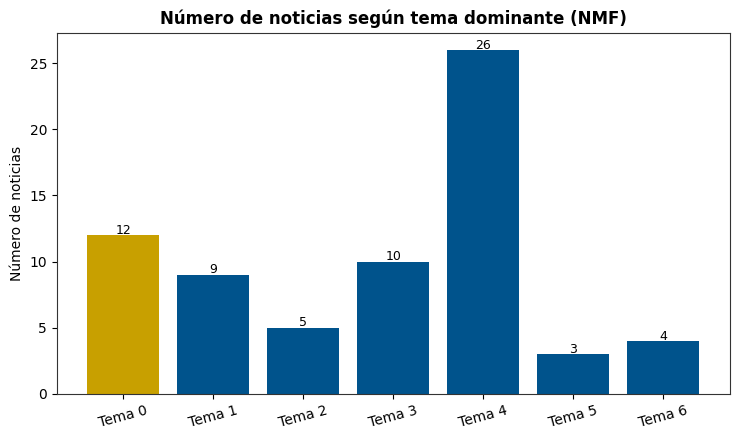

In [21]:
# =====================================================
# Distribución de noticias según su tema dominante
# =====================================================
tema_dominante = matriz_documento_tema.argmax(axis=1)
conteo_temas = pd.Series(tema_dominante).value_counts().sort_index()

plt.figure(figsize=(7.5, 4.5))
barras = plt.bar(
    [f"Tema {t}" for t in conteo_temas.index],
    conteo_temas.values,
    color=[COLOR_PRINCIPAL if t != 0 else COLOR_SECUNDARIO for t in conteo_temas.index],
)
plt.title("Número de noticias según tema dominante (NMF)")
plt.ylabel("Número de noticias")
plt.xticks(rotation=15)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, altura + 0.1, int(altura),
              ha="center", fontsize=9)

plt.tight_layout()
plt.show()

###  Estadísticas finales del modelo

In [22]:
# =====================================================
# Estadísticas generales del sistema
# =====================================================
similitudes_sin_diagonal = matriz_similitud[~np.eye(len(df_noticias), dtype=bool)]

print("=" * 55)
print("RESUMEN FINAL DEL MODELO")
print("=" * 55)
print(f"Noticias procesadas                 : {len(df_noticias)}")
print(f"Tamaño del vocabulario TF-IDF        : {matriz_tfidf.shape[1]}")
print(f"Número de temas (NMF)                : {NUM_TEMAS}")
print(f"Error de reconstrucción de NMF       : {modelo_nmf.reconstruction_err_:.4f}")
print(f"Similitud promedio entre noticias    : {similitudes_sin_diagonal.mean():.4f}")
print(f"Similitud máxima (excluyendo diagonal): {similitudes_sin_diagonal.max():.4f}")

RESUMEN FINAL DEL MODELO
Noticias procesadas                 : 69
Tamaño del vocabulario TF-IDF        : 3000
Número de temas (NMF)                : 7
Error de reconstrucción de NMF       : 7.3321
Similitud promedio entre noticias    : 0.2870
Similitud máxima (excluyendo diagonal): 1.0000
